<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import os
import torch
from sklearn.metrics import accuracy_score, classification_report
from PIL import Image
import pandas as pd
#from google.colab import drive
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
pd.set_option('display.max_columns', None)
print("All dependencies present.")

In [ ]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)
seed_val = 42
set_seed(seed_val)

In [ ]:
feats_df = pd.read_pickle("content/Images_Classified.pkl")
feats_df

In [ ]:
# TODO: Delete all images
# plot the model predicted class in feature space
def plotter(feat_1,feat_2):
  num_classes = 7
  classes = np.arange(0,num_classes)# list of unique clusters

  class_dfs = [] # list of dfs for each cluster

  for i in classes:
    df = feats_df[feats_df["classifier_pred_class"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

  fig, ax = plt.subplots()

  colors = ["red","green","blue","purple","orange","black","pink"]
  alpha = [1,1,1,1,1,1,1]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]

for p1 in params:
  for p2 in params:
    if p1 != p2:
      plotter(p1,p2)
      print(p1, " x ", p2)

In [ ]:
# make all of the params type float

feats_df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]] = feats_df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]].astype(float)

# do clusters in first 3 PCs

from mpl_toolkits import mplot3d

def threeD_plotter(feat_1,feat_2,feat_3, elevation=30, azi=90):
    num_classes = 7
    classes = np.arange(0,num_classes)# list of unique clusters

    class_dfs = [] # list of dfs for each cluster

    for i in classes:
      df = feats_df[feats_df["classifier_pred_class"] == i]
      df.reset_index(inplace = True, drop = True)
      class_dfs.append(df)

    # Creating 3D figure
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    colors = ["red","green","blue","purple","orange","black","pink"]
    alpha = [1,1,1,1,1,1,0]
    for j in classes:
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])


    leg = ax.legend(loc="upper left")

    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    # 360 Degree view
    ax.view_init(elevation, azi)
    plt.show()


params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]

for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(j,len(params)):
      if i != j and j != k:
        threeD_plotter(params[i],params[j],params[k])

In [ ]:
## First block of code nessesary for latter visualizations.
# plot ratios of params

# code switch for plotting. set to False to avoid verbose plotting
plot = False

def ratio_plotter(feat_1,feat_2):
  num_classes = 7
  classes = np.arange(0,num_classes)# list of unique clusters

  class_dfs = [] # list of dfs for each cluster

  for i in classes:
    df = feats_df[feats_df["classifier_pred_class"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

  fig, ax = plt.subplots()

  colors = ["red","green","blue","purple","orange","black","pink"]
  alpha = [1,1,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return


params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ## Dumps the feats_df[p0,p1,p2,p3] to numpy arrays and then divides them
          ratio_1 = np.array(feats_df[p0]).astype(float) / np.array(feats_df[p1]).astype(float)
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]).astype(float) / np.array(feats_df[p3]).astype(float)
          feats_df[p2 + "/" + p3] = ratio_2

          if plot:
              ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

print("Complete.")

In [ ]:
feats_df.head()

In [9]:
# Can be run independently as of 8/13/25
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ## Dumps the feats_df[p0,p1,p2,p3] to numpy arrays and then divides them
          ratio_1 = np.array(feats_df[p0]).astype(float) / np.array(feats_df[p1]).astype(float)
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]).astype(float) / np.array(feats_df[p3]).astype(float)
          feats_df[p2 + "/" + p3] = ratio_2

          counter += 1
print(counter)

print("Complete.")

# Needed for further visualizations
## This code creates a dictionary of all the features' attributes/properties. Each row (eg. 0 is a collection of values for a specific image)

# Defines features + params + params ratios
feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']  + list(feats_df.columns[13:111])

feats_extra = []

# creates a list of parameter properties (eg. Ua/Ui Mean, Min, Max, std)
for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra

num_classes = 7
classes = np.arange(0,num_classes)

class_dfs = [] 
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []

print(rows)

for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:feats[j].index(" ")]]).astype(float))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(std)

print(rows)

In [10]:
# Needed for further visualizations
cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
print(cluster_means_df)
cluster_means_df = cluster_means_df.transpose()
print("transpose complete:")
cluster_means_df.columns = feats

cluster_means_df

            0         1         2         3         4         5         6
0    0.033325  0.025055  0.030928  0.037981  0.034266  0.028643  0.033098
1    0.008363  0.008331  0.008339  0.012740  0.008429  0.008446  0.011286
2    0.051678  0.051681  0.051676  0.051569  0.051530  0.051375  0.050077
3    0.011129  0.011532  0.010270  0.008283  0.010423  0.010490  0.011845
4    0.087454  0.139736  0.092134  0.103806  0.116211  0.121616  0.043257
..        ...       ...       ...       ...       ...       ...       ...
495  0.000047  0.004865  0.140453  0.086581  0.067608  0.134350  0.114014
496  0.000000  0.000022  0.004887  0.140251  0.051635  0.197125  0.054867
497  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
498  0.000000  0.193500  0.357000  0.246500  0.261447  0.357539  0.236589
499  0.000000  0.002077  0.031665  0.050321  0.046121  0.060500  0.068044

[500 rows x 7 columns]
transpose complete:


,Ua mean,Ua min,Ua max,Ua std,Ui mean,Ui min,Ui max,Ui std,Ga mean,Ga min,Ga max,Ga std,Gi mean,Gi min,Gi max,Gi std,Da mean,Da min,Da max,Da std,Di mean,Di min,Di max,Di std,Ba mean,Ba min,Ba max,Ba std,Ua/Ui mean,Ua/Ui min,Ua/Ui max,Ua/Ui std,Ua/Ga mean,Ua/Ga min,Ua/Ga max,Ua/Ga std,Ua/Gi mean,Ua/Gi min,Ua/Gi max,Ua/Gi std,Ua/Da mean,Ua/Da min,Ua/Da max,Ua/Da std,Ua/Di mean,Ua/Di min,Ua/Di max,Ua/Di std,Ua/Ba mean,Ua/Ba min,Ua/Ba max,Ua/Ba std,Ga/Gi mean,Ga/Gi min,Ga/Gi max,Ga/Gi std,Ga/Da mean,Ga/Da min,Ga/Da max,Ga/Da std,Ga/Di mean,Ga/Di min,Ga/Di max,Ga/Di std,Ga/Ba mean,Ga/Ba min,Ga/Ba max,Ga/Ba std,Gi/Da mean,Gi/Da min,Gi/Da max,Gi/Da std,Gi/Di mean,Gi/Di min,Gi/Di max,Gi/Di std,Gi/Ba mean,Gi/Ba min,Gi/Ba max,Gi/Ba std,Da/Di mean,Da/Di min,Da/Di max,Da/Di std,Da/Ba mean,Da/Ba min,Da/Ba max,Da/Ba std,Di/Ba mean,Di/Ba min,Di/Ba max,Di/Ba std,Ui/Gi mean,Ui/Gi min,Ui/Gi max,Ui/Gi std,Ui/Da mean,Ui/Da min,Ui/Da max,Ui/Da std,Ui/Di mean,Ui/Di min,Ui/Di max,Ui/Di std,Ui/Ba mean,Ui/Ba min,Ui/Ba max,Ui/Ba std,num_spots mean,num_spots min,num_spots max,num_spots std,Mean mean,Mean min,Mean max,Mean std,Median mean,Median min,Median max,Median std,Area_mean mean,Area_mean min,Area_mean max,Area_mean std,Area_std mean,Area_std min,Area_std max,Area_std std,X_mean mean,X_mean min,X_mean max,X_mean std,X_std mean,X_std min,X_std max,X_std std,Y_mean mean,Y_mean min,Y_mean max,Y_mean std,Y_std mean,Y_std min,Y_std max,Y_std std,Perim._mean mean,Perim._mean min,Perim._mean max,Perim._mean std,Perim._std mean,Perim._std min,Perim._std max,Perim._std std,BX_mean mean,BX_mean min,BX_mean max,BX_mean std,BX_std mean,BX_std min,BX_std max,BX_std std,BY_mean mean,BY_mean min,BY_mean max,BY_mean std,BY_std mean,BY_std min,BY_std max,BY_std std,Width_mean mean,Width_mean min,Width_mean max,Width_mean std,Width_std mean,Width_std min,Width_std max,Width_std std,Height_mean mean,Height_mean min,Height_mean max,Height_mean std,Height_std mean,Height_std min,Height_std max,Height_std std,Major_mean mean,Major_mean min,Major_mean max,Major_mean std,Major_std mean,Major_std min,Major_std max,Major_std std,Minor_mean mean,Minor_mean min,Minor_mean max,Minor_mean std,Minor_std mean,Minor_std min,Minor_std max,Minor_std std,Angle_mean mean,Angle_mean min,Angle_mean max,Angle_mean std,Angle_std mean,Angle_std min,Angle_std max,Angle_std std,Circ._mean mean,Circ._mean min,Circ._mean max,Circ._mean std,Circ._std mean,Circ._std min,Circ._std max,Circ._std std,Feret_mean mean,Feret_mean min,Feret_mean max,Feret_mean std,Feret_std mean,Feret_std min,Feret_std max,Feret_std std,IntDen_mean mean,IntDen_mean min,IntDen_mean max,IntDen_mean std,IntDen_std mean,IntDen_std min,IntDen_std max,IntDen_std std,%Area_mean mean,%Area_mean min,%Area_mean max,%Area_mean std,%Area_std mean,%Area_std min,%Area_std max,%Area_std std,RawIntDen_mean mean,RawIntDen_mean min,RawIntDen_mean max,RawIntDen_mean std,RawIntDen_std mean,RawIntDen_std min,RawIntDen_std max,RawIntDen_std std,FeretX_mean mean,FeretX_mean min,FeretX_mean max,FeretX_mean std,FeretX_std mean,FeretX_std min,FeretX_std max,FeretX_std std,FeretY_mean mean,FeretY_mean min,FeretY_mean max,FeretY_mean std,FeretY_std mean,FeretY_std min,FeretY_std max,FeretY_std std,FeretAngle_mean mean,FeretAngle_mean min,FeretAngle_mean max,FeretAngle_mean std,FeretAngle_std mean,FeretAngle_std min,FeretAngle_std max,FeretAngle_std std,MinFeret_mean mean,MinFeret_mean min,MinFeret_mean max,MinFeret_mean std,MinFeret_std mean,MinFeret_std min,MinFeret_std max,MinFeret_std std,AR_mean mean,AR_mean min,AR_mean max,AR_mean std,AR_std mean,AR_std min,AR_std max,AR_std std,Round_mean mean,Round_mean min,Round_mean max,Round_mean std,Round_std mean,Round_std min,Round_std max,Round_std std,Solidity_mean mean,Solidity_mean min,Solidity_mean max,Solidity_mean std,Solidity_std mean,Solidity_std min,Solidity_std max,Solidity_std std,num_spots_inverted mean,num_spots_inverted min,num_spots_inverted max,num_spots_inverted std,Mean_inverted 

Ua


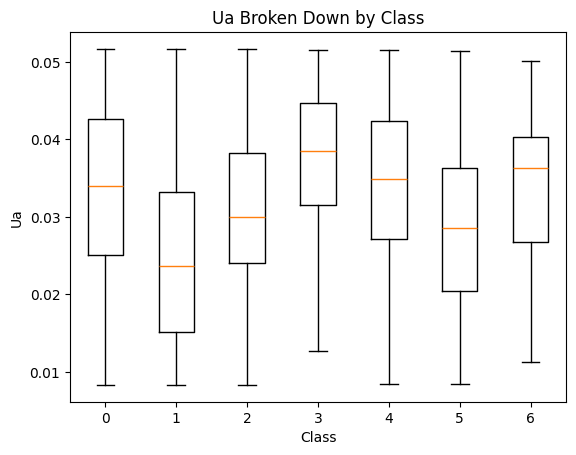

Ui


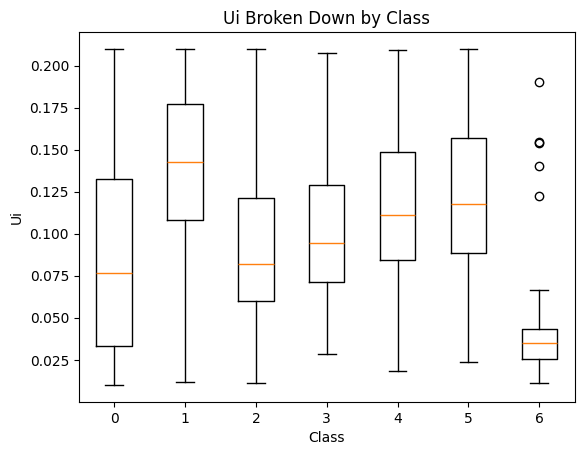

Ga


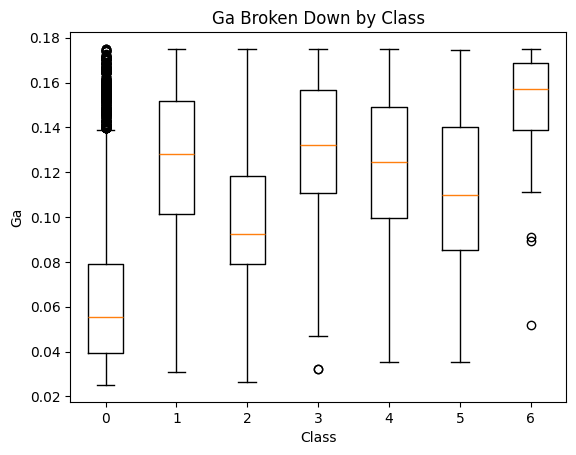

Gi


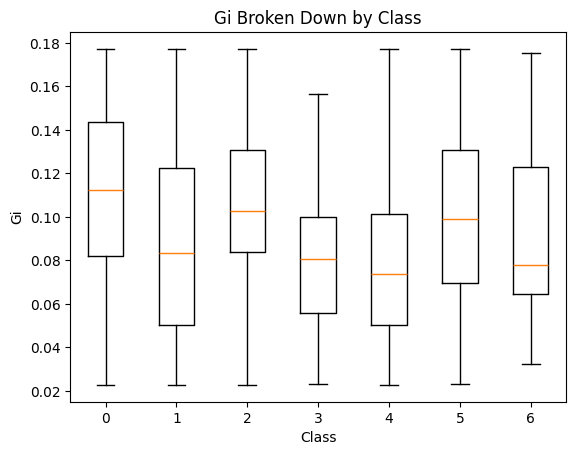

Da


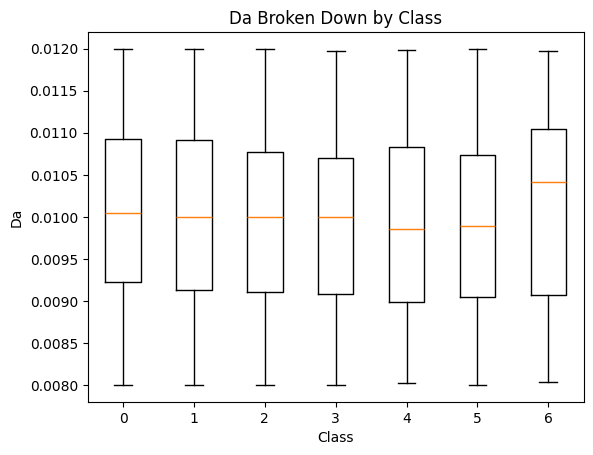

Di


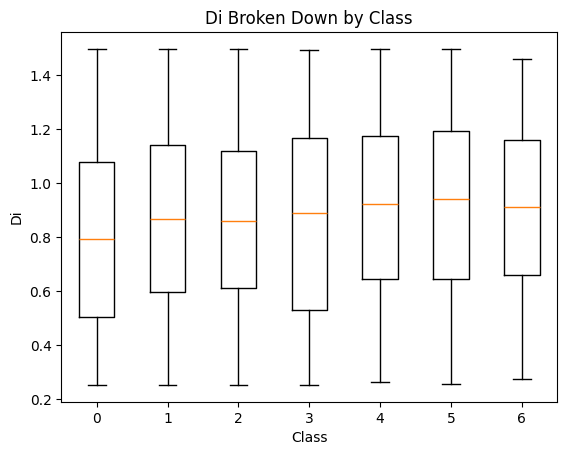

Ba


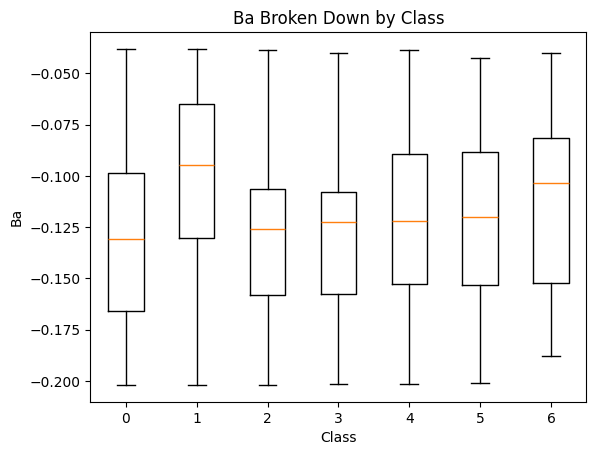

Ua/Ui


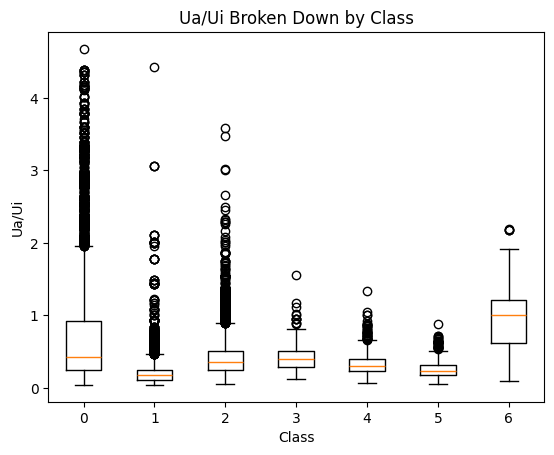

Ua/Ga


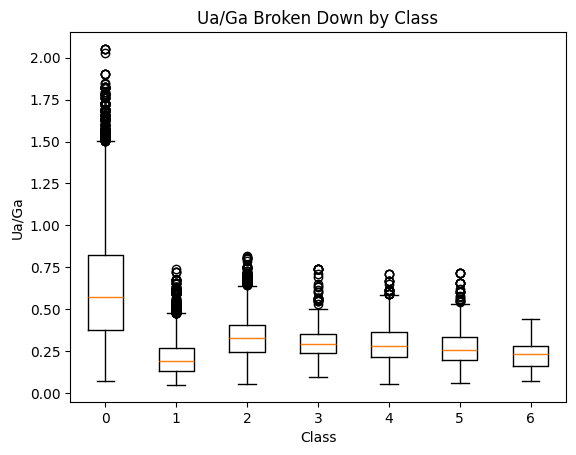

Ua/Gi


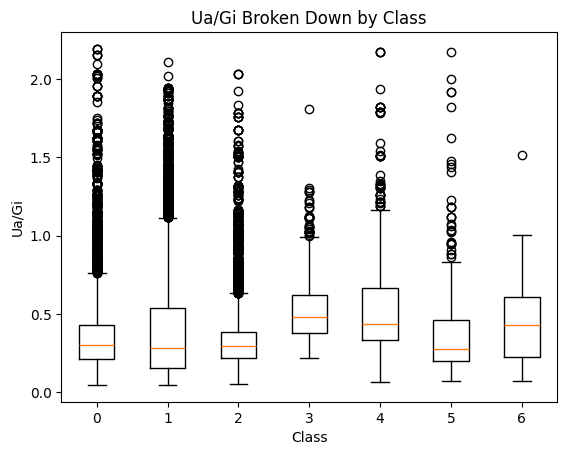

Ua/Da


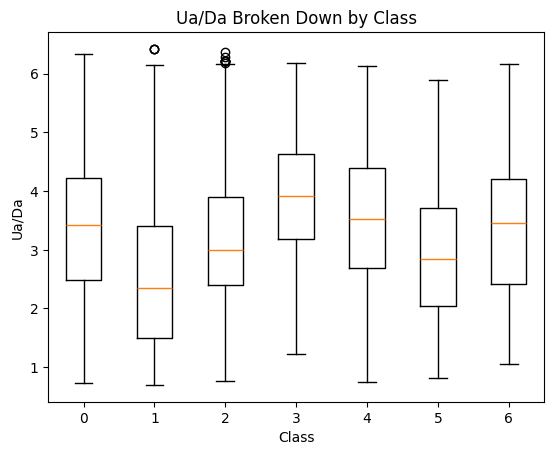

Ua/Di


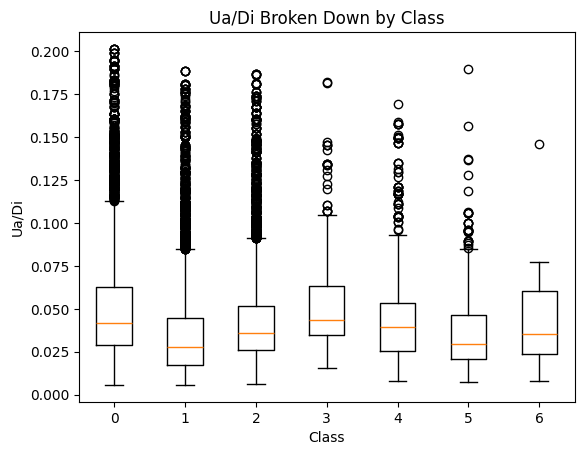

Ua/Ba


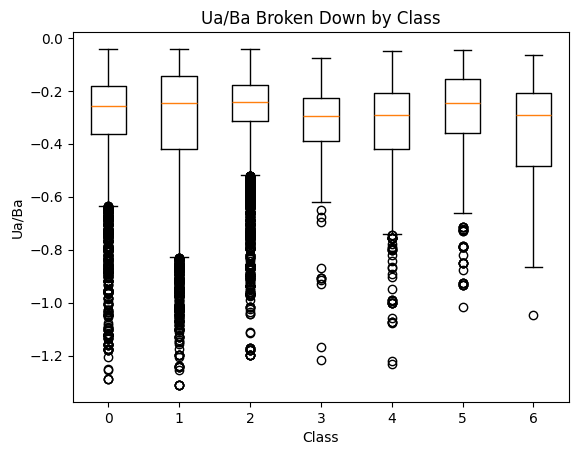

Ga/Gi


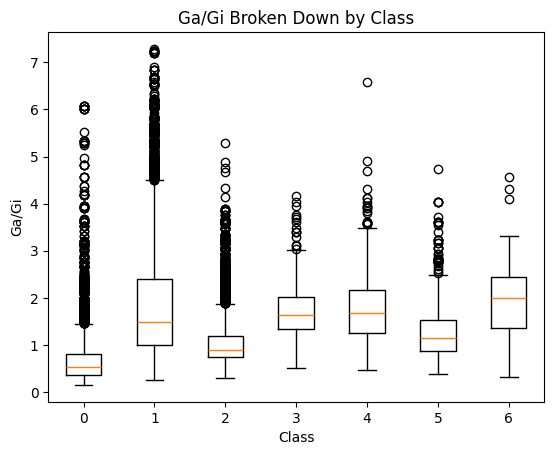

Ga/Da


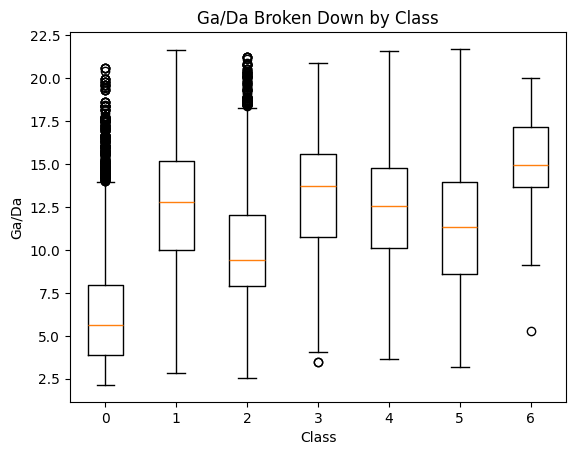

Ga/Di


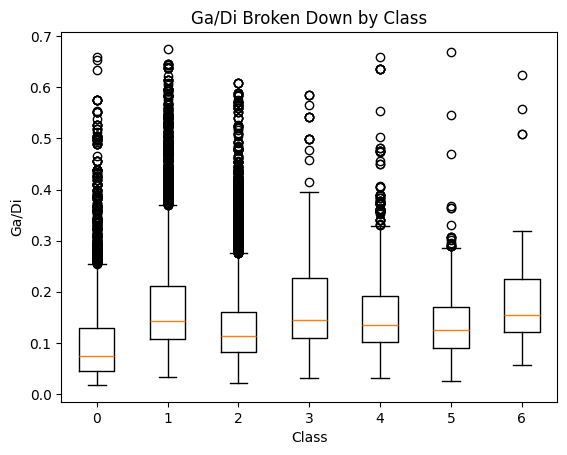

Ga/Ba


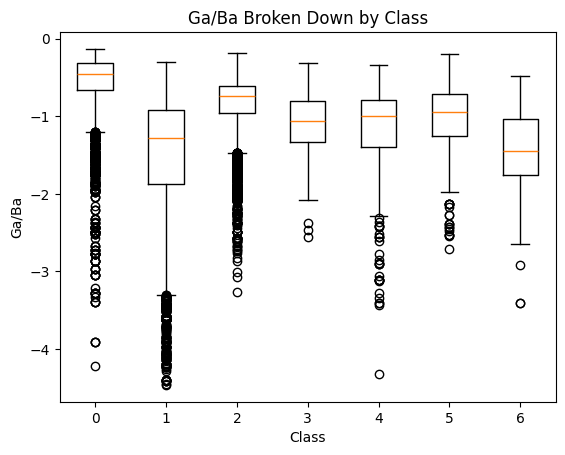

Gi/Da


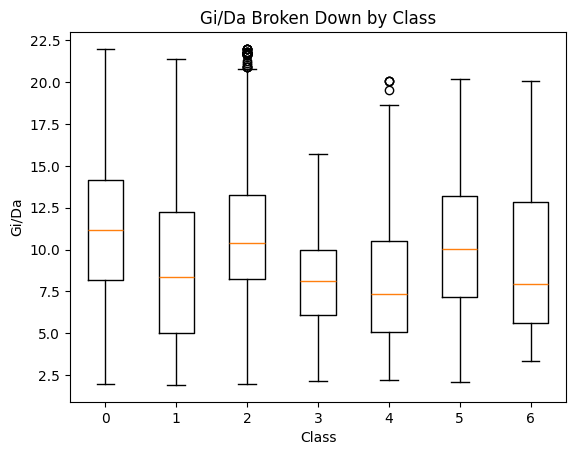

Gi/Di


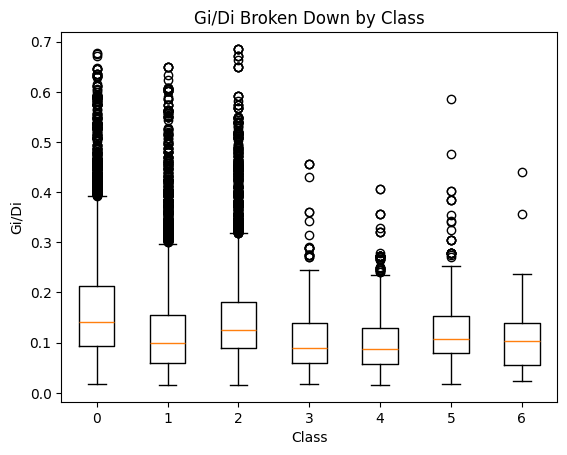

Gi/Ba


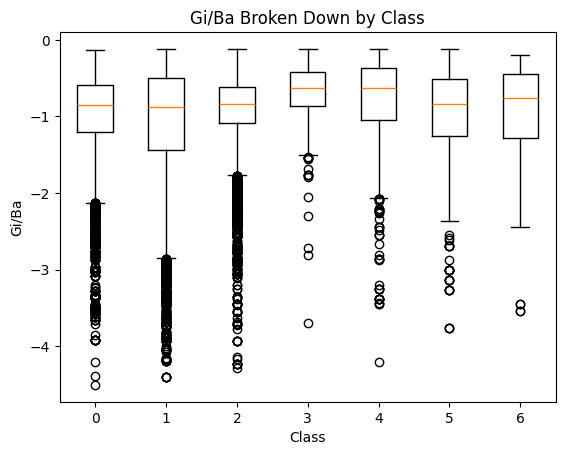

Da/Di


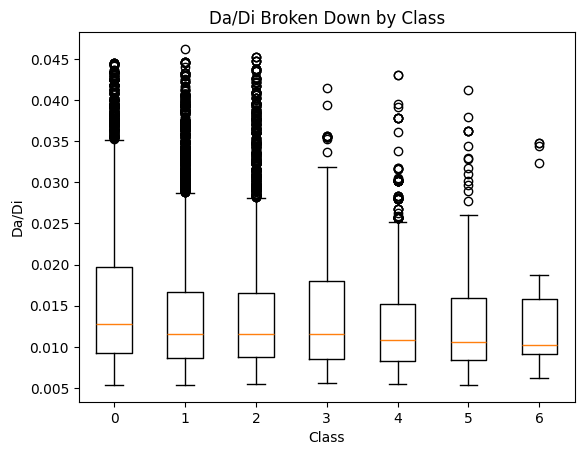

Da/Ba


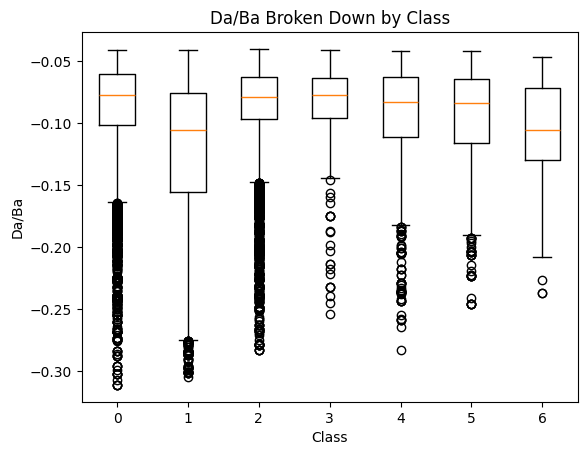

Di/Ba


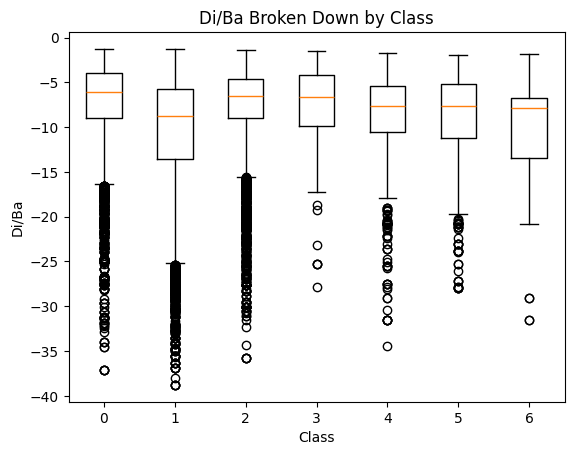

Ui/Gi


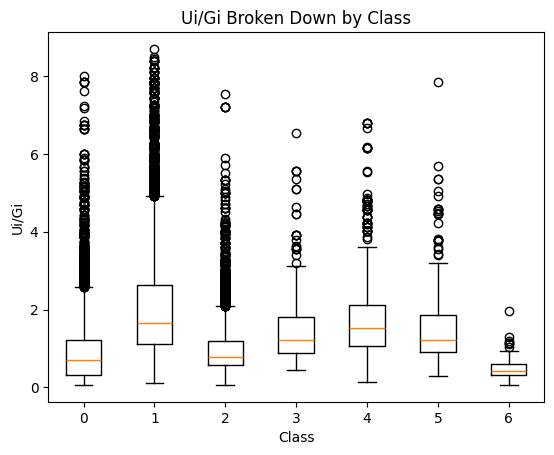

Ui/Da


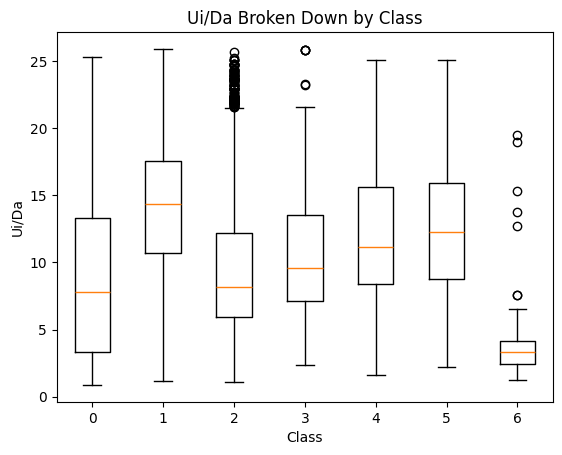

Ui/Di


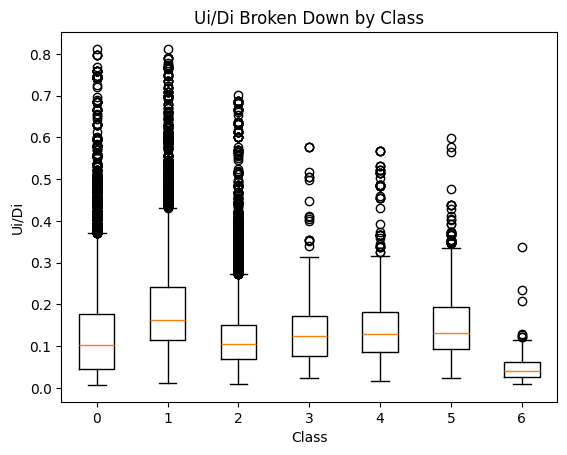

In [ ]:
## Distribution of parameters and parameter ratios in each cluster 

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:111])

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
   df = feats_df[feats_df["classifier_pred_class"] == i]
   df.reset_index(inplace = True, drop = True)
   class_dfs.append(df)
   rows[str(i)] = []

for feature in feats:
  list_of_lists = []
  print(feature)
  for i in range(len(class_dfs)):
    #print(f"We are in class {i}")
    values = np.array(class_dfs[i][feature]).astype(float)
    #print(values)
    list_of_lists.append(list(values))
  plt.boxplot(list_of_lists,positions=classes)
  plt.title(feature + " Broken Down by Class")
  plt.xlabel("Class")
  plt.ylabel(feature)
  plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler,MaxAbsScaler

## 1 box with 7 params on the same graph

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters
#params = [["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
#       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
#       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + (feats_df.columns[13:111])]
params_shortened = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
key = params_shortened
num_values = len(key) + 1

sc = StandardScaler()

## Loop through classes
for i in classes:
  listoflists = []
  df = feats_df[feats_df["classifier_pred_class"] == i]
  classification = i
  for param in key:
    # Creates a numpy array of all values for the parameters
    print(param)
    numbers = np.array(df[param]).astype(float)
    # scale the data
    numbers = sc.fit_transform(numbers.reshape(-1,1)).flatten()
    numbers.reshape(1,-1)
    #print(numbers)
    # np.append(array, values)
    listoflists.append(numbers)
    #print(numbers)
  plt.boxplot(
      listoflists,
      positions=np.arange(0,num_values - 1).tolist(),
      showfliers=False,
      labels=["Ua","Ui","Ga","Gi","Da","Di","Ba"]
  )
  plt.title("Class " + str(classification))
  plt.xlabel("Parameters")
  plt.ylabel("Values")
  plt.show()

## Also, interpretations of data.

In [ ]:
# print bar plots for each param based on class
# May be confusing as each parameter has a different lower range

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:111])

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []

colors = ["red","green","blue","purple","orange","turquoise","pink"]

for i in range(len(feats)):
  # Defines what feature we are working with. Dependant on value of i.
  param = feats[i]
  # Outputs the param name
  print(param)
  # Pulls all column names and adds them to param_list
  param_list = cluster_means_df.columns
  # Locates i*4 in param_list
  means = cluster_means_df[param_list[i*4]]
  print(list(means))
  mins = cluster_means_df[param_list[(i*4) + 1]]
  print(list(mins))
  maxes = cluster_means_df[param_list[(i*4) + 2]]
  print(list(maxes))
  stds = cluster_means_df[param_list[(i*4) + 3]]
  print(list(stds))

  # bar plots
  fig, ax = plt.subplots()
  ax.bar(["0","1","2","3","4","5","6"], means, width = 0.3, color = colors[i%6], yerr = stds)



  #set min and max points
  ax.scatter(classes, mins, color = "black")
  ax.scatter(classes, maxes, color = "black")



  ax.set(title = "Mean " + param)

  plt.show()

In [ ]:
# scale each param so we can plot them next to each other
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
# Creates a df excluding all columns but Ua through Ba
params_df = feats_df[params]

from sklearn.preprocessing import MinMaxScaler

feats = []

# picks a parameter
for param in  params:
  # instantiates a MinMaxScaler object
  sc = MinMaxScaler()
  # Reshapes the data and turns it into a column vector and dumps it into a numpy array. Turns it from a list to a COLUMN
  param_arr = np.array(params_df[param]).reshape(-1,1)
  # Creates a scaled parameter array of the column array (see above)
  param_arr_scaled = sc.fit_transform(param_arr) # Scales (0,1  )
  # Creates a new column of the parameters' scaled version
  feats_df[param + "_scaled"] = param_arr_scaled
  #feats.append(param + "_scaled")

# Defines the features
# Should we be hardcoding this?
feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

feats_extra = []

for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra
print(len(feats))

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []

for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(std)

cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df

In [ ]:
# 6/11/25
# Do all 7 main params on the same plot

# print bar plots for each param based on class

feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']
num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)

colors = ["red","green","blue","purple","orange","turquoise","pink"]
fig, ax = plt.subplots(figsize = (12,8))
for i in range(len(feats)):
  param = feats[i]
  print(param)
  param_list = cluster_means_df.columns
  means = cluster_means_df[param_list[i*4]]
  print(list(means))
  mins = cluster_means_df[param_list[(i*4) + 1]]
  print(list(mins))
  maxes = cluster_means_df[param_list[(i*4) + 2]]
  print(list(maxes))
  stds = cluster_means_df[param_list[(i*4) + 3]]
  print(list(stds))

  # bar plots
  width = 0.32
  # fig, ax = plt.subplots()
  ## ?
  bar_pos = (np.array([0,3,6,9,12,15,18]) + width*i )
  ax.bar(bar_pos, means, width = width, color = colors[i%6], yerr = stds, label = param)



  #set min and max points
  ax.scatter(bar_pos, mins, color = "black")
  ax.scatter(bar_pos, maxes, color = "black")



ax.set(title = "Mean Params By Classes")
ax.legend()

# leg = ax.legend(['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
#         'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled'], loc="upper left")


# leg = ax.get_legend()
# print(type(leg.legend_handles[0]))
# leg.legendHandles[0].set_color('red')
# leg.legendHandles[1].set_color('green')
# leg.legendHandles[2].set_color('blue')
# leg.legendHandles[3].set_color('purple')
# leg.legendHandles[4].set_color('orange')
# leg.legendHandles[5].set_color('turquoise')
# leg.legendHandles[6].set_color('pink')

ax.set_xticks([1,4,7,10,13,16,19])
ax.set_xticklabels(["0",'1', '2', '3', '4', '5', "6"])

plt.show()

In [ ]:
# import pillows library
# TODO: Clean and reformat
from PIL import Image, ImageSequence

def show_image(image_num = 4242):
  # define the image path
  path = os.getcwd() + feats_df["dir"][image_num] + '/' + feats_df["path"][image_num]

  # open the image
  img = Image.open(str(path))

  # convert the image into a numpy array
  img = np.array(img)

  #view the image using matplotlib plt.imshow
  plt.imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
  print(path)

show_image()

# print(img[0,199])

In [ ]:
# plot some dependencies

single_dic = pd.read_pickle("content/2024-08-28_single_param_scans.pkl")

keys = list(single_dic.keys())
# feat_1 = "Ua"
feat_2 = "num_spots"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(5):

    # pull up the dataframe for the specific class
    df = single_dic[keys[i]]
    df = df[df["cluster"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i] + "_x"].astype(float)
    y = df[feat_2 + "_x"].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()